# 35 - TCGA-BRCA Fisher Overlap Analysis

Fisher information overlap between forget and retain sets on the TCGA-BRCA
baseline model. Tests whether the structural theory (Proposition 1) generalizes
from scRNA-seq to bulk RNA-seq.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import torch
import json
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
from pathlib import Path
from collections import defaultdict

from utils import set_global_seed, GLOBAL_SEED, DEVICE
from vae import VAE
from fisher_utils import (
    AnnDataDataset, compute_vae_fisher,
    cosine_sim, effective_rank, top_k_overlap, vae_layer_category
)
from torch.utils.data import DataLoader

set_global_seed(GLOBAL_SEED)
plt.style.use('seaborn-v0_8-whitegrid')

DATA_DIR = Path('../data/tcga_brca')
OUTPUT_DIR = Path('../outputs/tcga_brca')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## Compute Fisher diagonals

In [2]:
adata = sc.read_h5ad(DATA_DIR / 'tcga_brca_processed.h5ad')
with open(OUTPUT_DIR / 'split_structured.json') as f:
    split = json.load(f)

baseline_ckpt = torch.load(OUTPUT_DIR / 'baseline' / 'best_model.pt', map_location=DEVICE)
config = baseline_ckpt['config']
model_config = {k: v for k, v in config.items()
                if k in ['input_dim', 'latent_dim', 'hidden_dims', 'likelihood', 'dropout', 'use_layer_norm']}
model = VAE(**model_config).to(DEVICE)
model.load_state_dict(baseline_ckpt['model_state_dict'])

DAMPING = 1e-8
forget_loader = DataLoader(AnnDataDataset(adata, split['forget_indices']), batch_size=128, shuffle=False)
retain_loader = DataLoader(AnnDataDataset(adata, split['retain_indices']), batch_size=128, shuffle=False)

fisher_forget, n_forget = compute_vae_fisher(model, forget_loader, DEVICE, damping=DAMPING)
fisher_retain, n_retain = compute_vae_fisher(model, retain_loader, DEVICE, damping=DAMPING)

flat_forget = torch.cat([fisher_forget[n].flatten() for n in sorted(fisher_forget.keys())])
flat_retain = torch.cat([fisher_retain[n].flatten() for n in sorted(fisher_retain.keys())])
global_cosine = cosine_sim(flat_forget, flat_retain)

# Per-layer
layer_f, layer_r = defaultdict(list), defaultdict(list)
for name in sorted(fisher_forget.keys()):
    cat = vae_layer_category(name)
    layer_f[cat].append(fisher_forget[name].flatten())
    layer_r[cat].append(fisher_retain[name].flatten())

per_layer = {}
for cat in ['Encoder', 'Bottleneck', 'Decoder hidden', 'Decoder output']:
    if cat in layer_f:
        f, r = torch.cat(layer_f[cat]), torch.cat(layer_r[cat])
        per_layer[cat] = cosine_sim(f, r)

# PBMC reference
pbmc = {'Encoder': 0.273, 'Bottleneck': 0.291, 'Decoder hidden': 0.232, 'Decoder output': 0.362}
pbmc_global = 0.306

## Per-layer comparison with PBMC

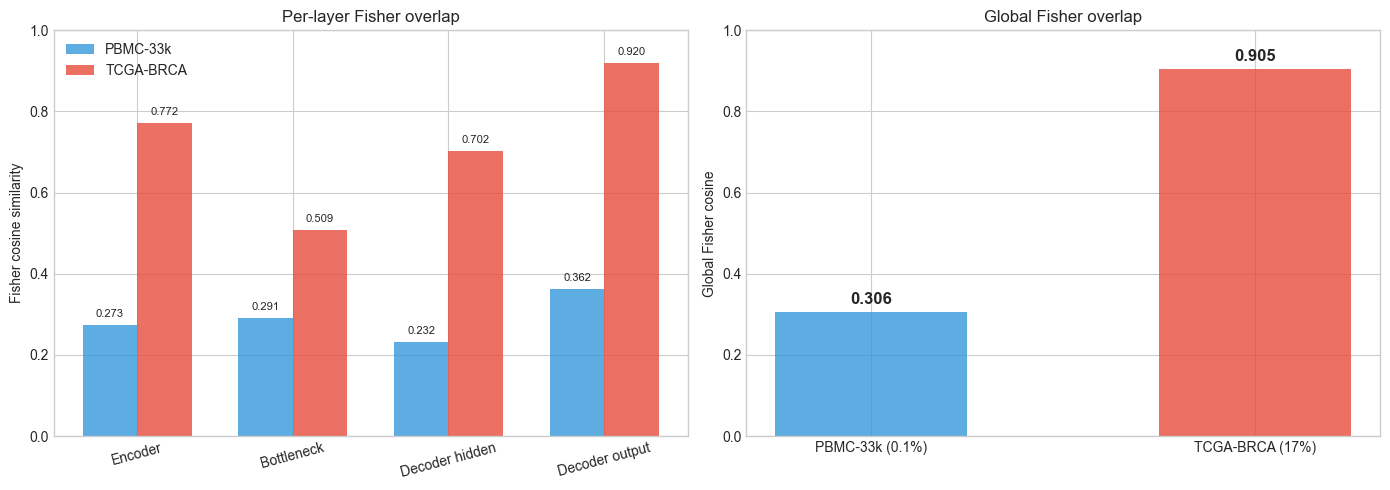

In [3]:
categories = ['Encoder', 'Bottleneck', 'Decoder hidden', 'Decoder output']
tcga_vals = [per_layer[c] for c in categories]
pbmc_vals = [pbmc[c] for c in categories]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(categories))
w = 0.35
axes[0].bar(x - w/2, pbmc_vals, w, label='PBMC-33k', color='#3498db', alpha=0.8)
axes[0].bar(x + w/2, tcga_vals, w, label='TCGA-BRCA', color='#e74c3c', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories, rotation=15)
axes[0].set_ylabel('Fisher cosine similarity')
axes[0].set_title('Per-layer Fisher overlap')
axes[0].legend()
axes[0].set_ylim(0, 1.0)
for i, (p, t) in enumerate(zip(pbmc_vals, tcga_vals)):
    axes[0].text(i - w/2, p + 0.02, f'{p:.3f}', ha='center', fontsize=8)
    axes[0].text(i + w/2, t + 0.02, f'{t:.3f}', ha='center', fontsize=8)

global_vals = [pbmc_global, global_cosine]
bar_labels = ['PBMC-33k (0.1%)', 'TCGA-BRCA (17%)']
bars = axes[1].bar(bar_labels, global_vals, color=['#3498db', '#e74c3c'], alpha=0.8, width=0.5)
axes[1].set_ylabel('Global Fisher cosine')
axes[1].set_title('Global Fisher overlap')
axes[1].set_ylim(0, 1.0)
for bar, val in zip(bars, global_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.3f}',
                 ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fisher_overlap_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
rows = [{'Layer': 'Global', 'PBMC-33k': pbmc_global, 'TCGA-BRCA': global_cosine,
         'Ratio': global_cosine / pbmc_global}]
for cat in categories:
    rows.append({'Layer': cat, 'PBMC-33k': pbmc[cat], 'TCGA-BRCA': per_layer[cat],
                 'Ratio': per_layer[cat] / pbmc[cat]})
pd.DataFrame(rows).set_index('Layer').style.format('{:.3f}')

,PBMC-33k,TCGA-BRCA,Ratio
Layer,,,
Global,0.306,0.905,2.958
Encoder,0.273,0.772,2.828
Bottleneck,0.291,0.509,1.749
Decoder hidden,0.232,0.702,3.026
Decoder output,0.362,0.920,2.542


## Gene-level overlap

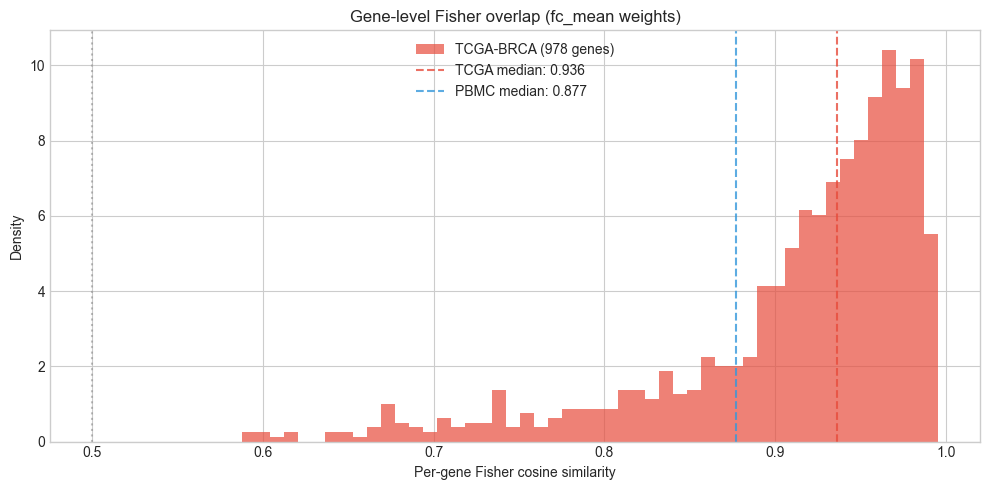

In [5]:
fc_mean_key = [k for k in fisher_forget.keys() if 'fc_mean' in k and 'weight' in k][0]
fm_f, fm_r = fisher_forget[fc_mean_key], fisher_retain[fc_mean_key]
n_genes = fm_f.shape[0]

gene_cosines = np.array([cosine_sim(fm_f[g], fm_r[g]) for g in range(n_genes)])

pbmc_fisher_raw = json.load(open('../outputs/p6/fisher_overlap_results.json'))
pbmc_gene = pbmc_fisher_raw.get('gene_analysis', {})
pbmc_median = pbmc_gene.get('median_cosine', 0.877)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(gene_cosines, bins=50, alpha=0.7, color='#e74c3c',
        label=f'TCGA-BRCA ({n_genes} genes)', density=True)
ax.axvline(np.median(gene_cosines), color='#e74c3c', ls='--', alpha=0.8,
           label=f'TCGA median: {np.median(gene_cosines):.3f}')
ax.axvline(pbmc_median, color='#3498db', ls='--', alpha=0.8,
           label=f'PBMC median: {pbmc_median:.3f}')
ax.axvline(0.5, color='gray', ls=':', alpha=0.5)
ax.set_xlabel('Per-gene Fisher cosine similarity')
ax.set_ylabel('Density')
ax.set_title('Gene-level Fisher overlap (fc_mean weights)')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fisher_gene_level.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
n_above_05 = int((gene_cosines > 0.5).sum())
pd.DataFrame({
    'Metric': ['Genes with cos > 0.5', 'Median cosine', 'Mean cosine', 'Total genes'],
    'TCGA-BRCA': [
        f'{n_above_05}/{n_genes} ({100*n_above_05/n_genes:.0f}%)',
        f'{np.median(gene_cosines):.3f}',
        f'{np.mean(gene_cosines):.3f}',
        n_genes
    ],
    'PBMC-33k': [
        f'{pbmc_gene.get("n_genes_cos_gt_0.5", 1462)}/2000 (73%)',
        f'{pbmc_median:.3f}',
        'N/A',
        2000
    ],
}).set_index('Metric')

,TCGA-BRCA,PBMC-33k
Metric,,
Genes with cos > 0.5,978/978 (100%),1462/2000 (73%)
Median cosine,0.936,0.877
Mean cosine,0.912,N/A
Total genes,978,2000


Fisher overlap on TCGA-BRCA is substantially higher than PBMC across every layer.
100% of genes have cosine above 0.5.

## Log-Fisher scatter

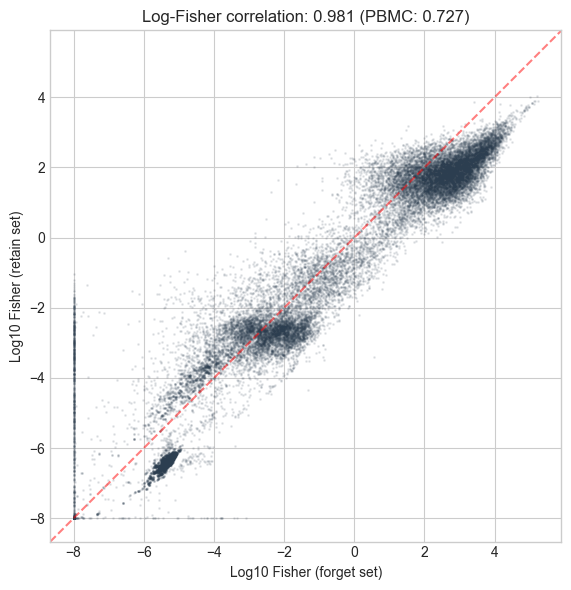

In [7]:
log_f = torch.log10(flat_forget.clamp(min=1e-30))
log_r = torch.log10(flat_retain.clamp(min=1e-30))
log_corr = float(torch.corrcoef(torch.stack([log_f, log_r]))[0, 1].item())

fig, ax = plt.subplots(figsize=(6, 6))
idx = np.random.choice(len(log_f), min(50000, len(log_f)), replace=False)
ax.scatter(log_f.numpy()[idx], log_r.numpy()[idx], s=1, alpha=0.1, c='#2c3e50')
ax.set_xlabel('Log10 Fisher (forget set)')
ax.set_ylabel('Log10 Fisher (retain set)')
title = f'Log-Fisher correlation: {log_corr:.3f} (PBMC: 0.727)'
ax.set_title(title)
lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, 'r--', alpha=0.5)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fisher_log_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## Save results

In [8]:
results = {
    'dataset': 'TCGA-BRCA',
    'damping': DAMPING,
    'n_params': int(flat_forget.shape[0]),
    'n_forget': n_forget,
    'n_retain': n_retain,
    'global_cosine': global_cosine,
    'global_eff_rank_forget': effective_rank(flat_forget),
    'global_eff_rank_retain': effective_rank(flat_retain),
    'per_layer': {k: {'cosine': v} for k, v in per_layer.items()},
    'gene_level': {
        'n_genes': int(n_genes),
        'n_genes_above_0.5': n_above_05,
        'median_cosine': float(np.median(gene_cosines)),
    },
    'log_fisher_correlation': log_corr,
    'comparison_pbmc': {
        'global_cosine': 0.306,
        'gene_level_median': 0.877,
        'log_fisher_corr': 0.727,
    },
}
with open(OUTPUT_DIR / 'fisher_overlap_results.json', 'w') as f:
    json.dump(results, f, indent=2)

## Summary

| Output | Path |
|--------|------|
| Per-layer comparison | `outputs/tcga_brca/fisher_overlap_comparison.png` |
| Gene-level histogram | `outputs/tcga_brca/fisher_gene_level.png` |
| Log-Fisher scatter | `outputs/tcga_brca/fisher_log_correlation.png` |
| Results JSON | `outputs/tcga_brca/fisher_overlap_results.json` |